1. Compare DoG, Harris, Shi-Tomasi, and FAST feature detectors for repeatability, speed, and number of features detected. Examine scale, translation, and rotation using camera-captured images. Do not digitally rotate or scale the images.


In [31]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "images_hw2").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "homework_2"))
from importlib import import_module, reload
reload(import_module("utils.Shi-Tomasi"))
reload(import_module("utils.ANMS"))
from utils import FeatureComparison as comparison
comparison = reload(comparison)
sequences = comparison.load_sequences(ROOT)


In [32]:
# Experiment settings: change a value and rerun this cell and the result cells below.
comparison.SETTINGS.update({
    "dog_threshold": 0.03,          # DoG peak threshold
    "harris_threshold": 0.01,       # fraction of maximum Harris response
    "shi_quality": 0.01,            # Shi-Tomasi quality level
    "fast_threshold": 20,           # FAST intensity difference
    "registration_ratio": 0.70,       # SIFT matches used to estimate the homography
    "ransac_pixels": 3.0,             # homography inlier distance
    "repeatability_pixels": 5.0,     # detector repeatability distance
    "geometric_match_pixels": 5.0,   # correct-match label distance
    "match_ratio": 0.75,             # descriptor acceptance threshold
    "anms_keep": 300,                # points used by each descriptor
    "anms_robust": 0.90,              # ANMS stronger-point factor
})
ANMS_DEMO_KEEP = 100
print("Settings:", comparison.SETTINGS, "ANMS demo points:", ANMS_DEMO_KEEP)


Settings: {'dog_threshold': 0.03, 'harris_threshold': 0.01, 'shi_quality': 0.01, 'fast_threshold': 20, 'registration_ratio': 0.7, 'ransac_pixels': 3.0, 'repeatability_pixels': 5.0, 'geometric_match_pixels': 5.0, 'match_ratio': 0.75, 'anms_keep': 300, 'anms_robust': 0.9} ANMS demo points: 100


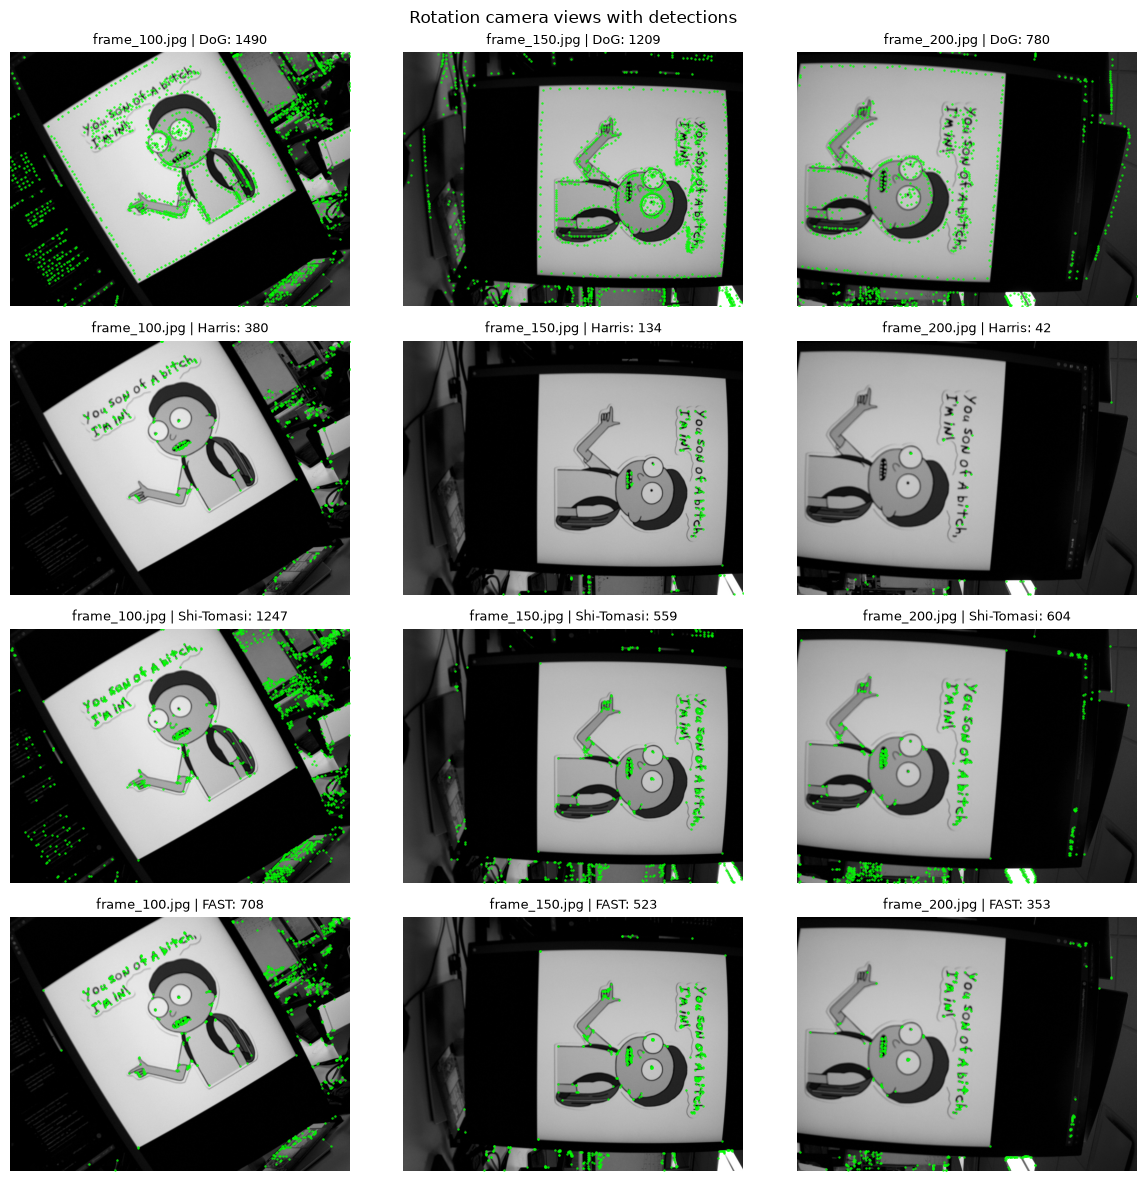

In [33]:
comparison.show_detector_views(sequences, "rotation")


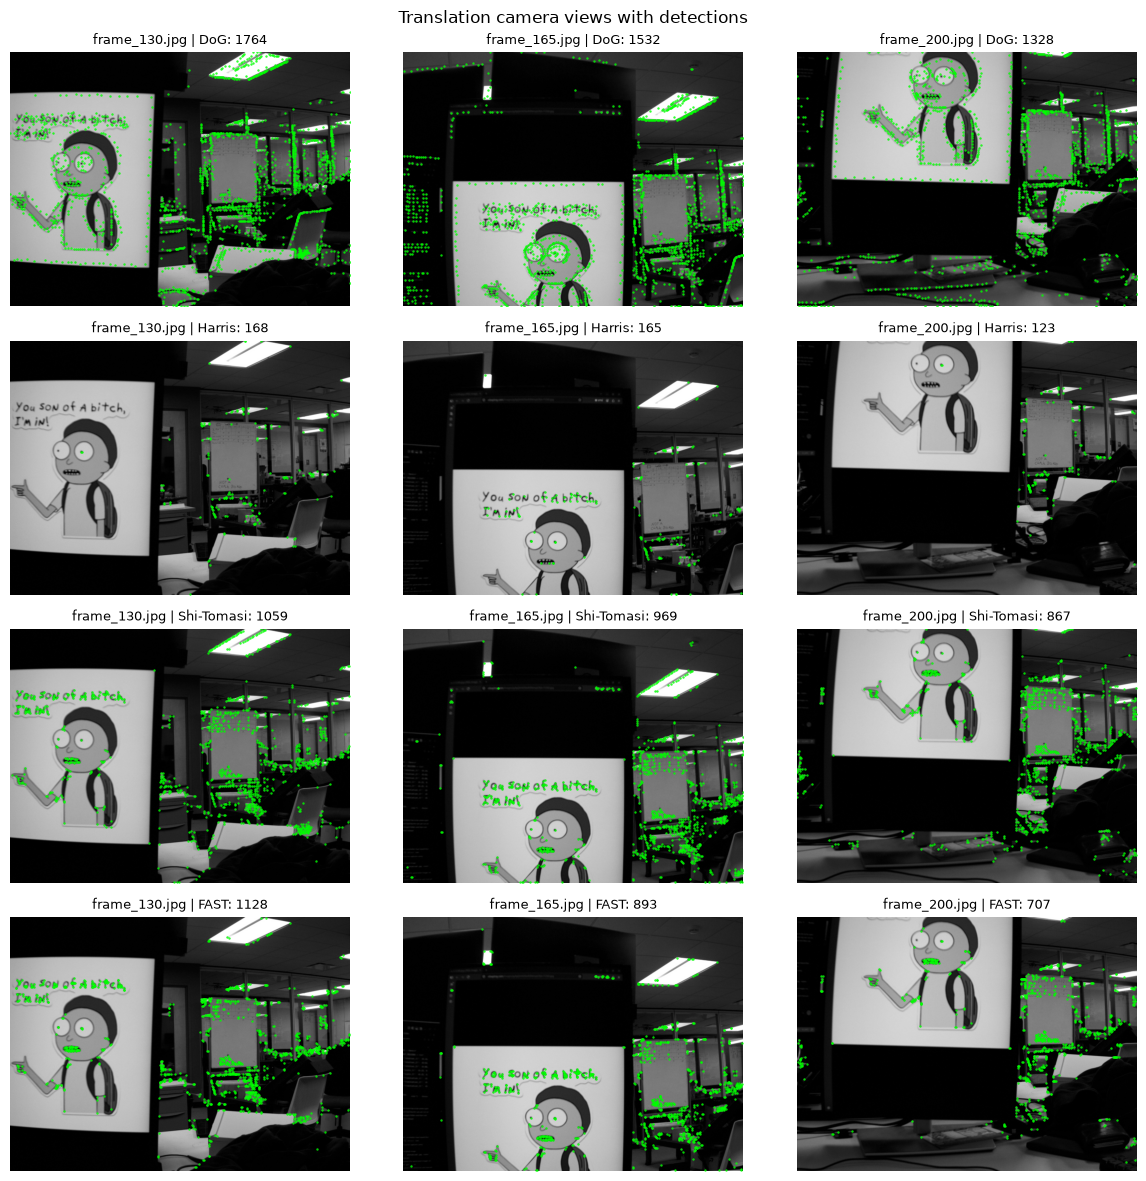

In [34]:
comparison.show_detector_views(sequences, "translation")


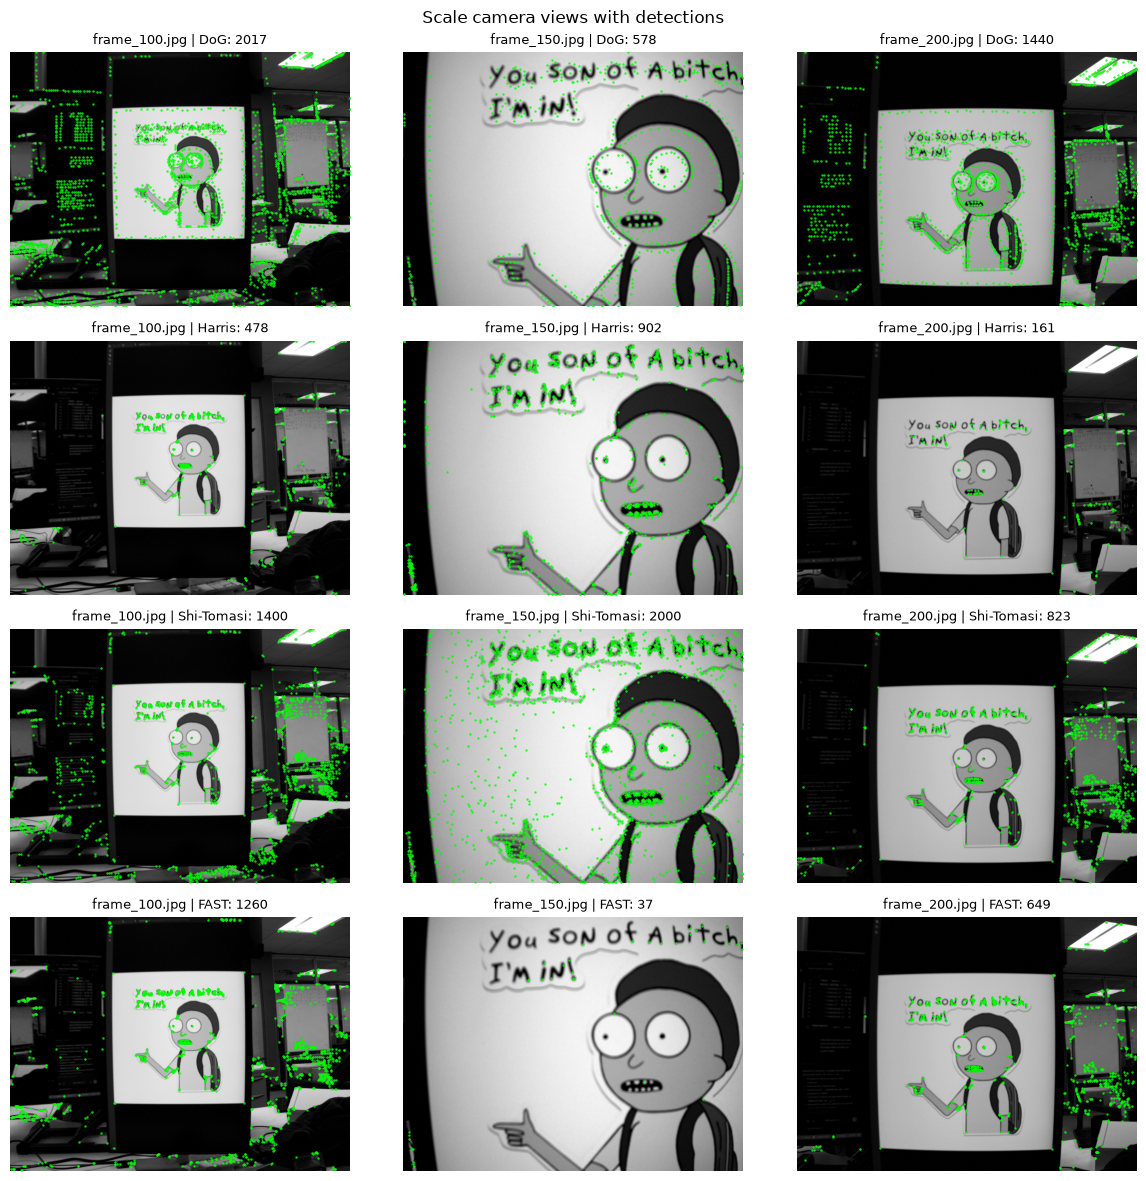

In [35]:
comparison.show_detector_views(sequences, "scale")


                        features  milliseconds  repeatability
motion      detector                                         
rotation    DoG         1298.667       892.598          0.585
            FAST         591.500         1.547          0.601
            Harris       199.500        26.163          0.412
            Shi-Tomasi   914.833        16.027          0.567
scale       DoG         1232.833       706.128          0.465
            FAST         572.167         1.344          0.444
            Harris       391.833        24.659          0.399
            Shi-Tomasi  1060.000        17.783          0.571
translation DoG         1657.000       805.114          0.471
            FAST        1051.400         1.879          0.522
            Harris       228.200        25.558          0.475
            Shi-Tomasi  1097.000        16.231          0.526


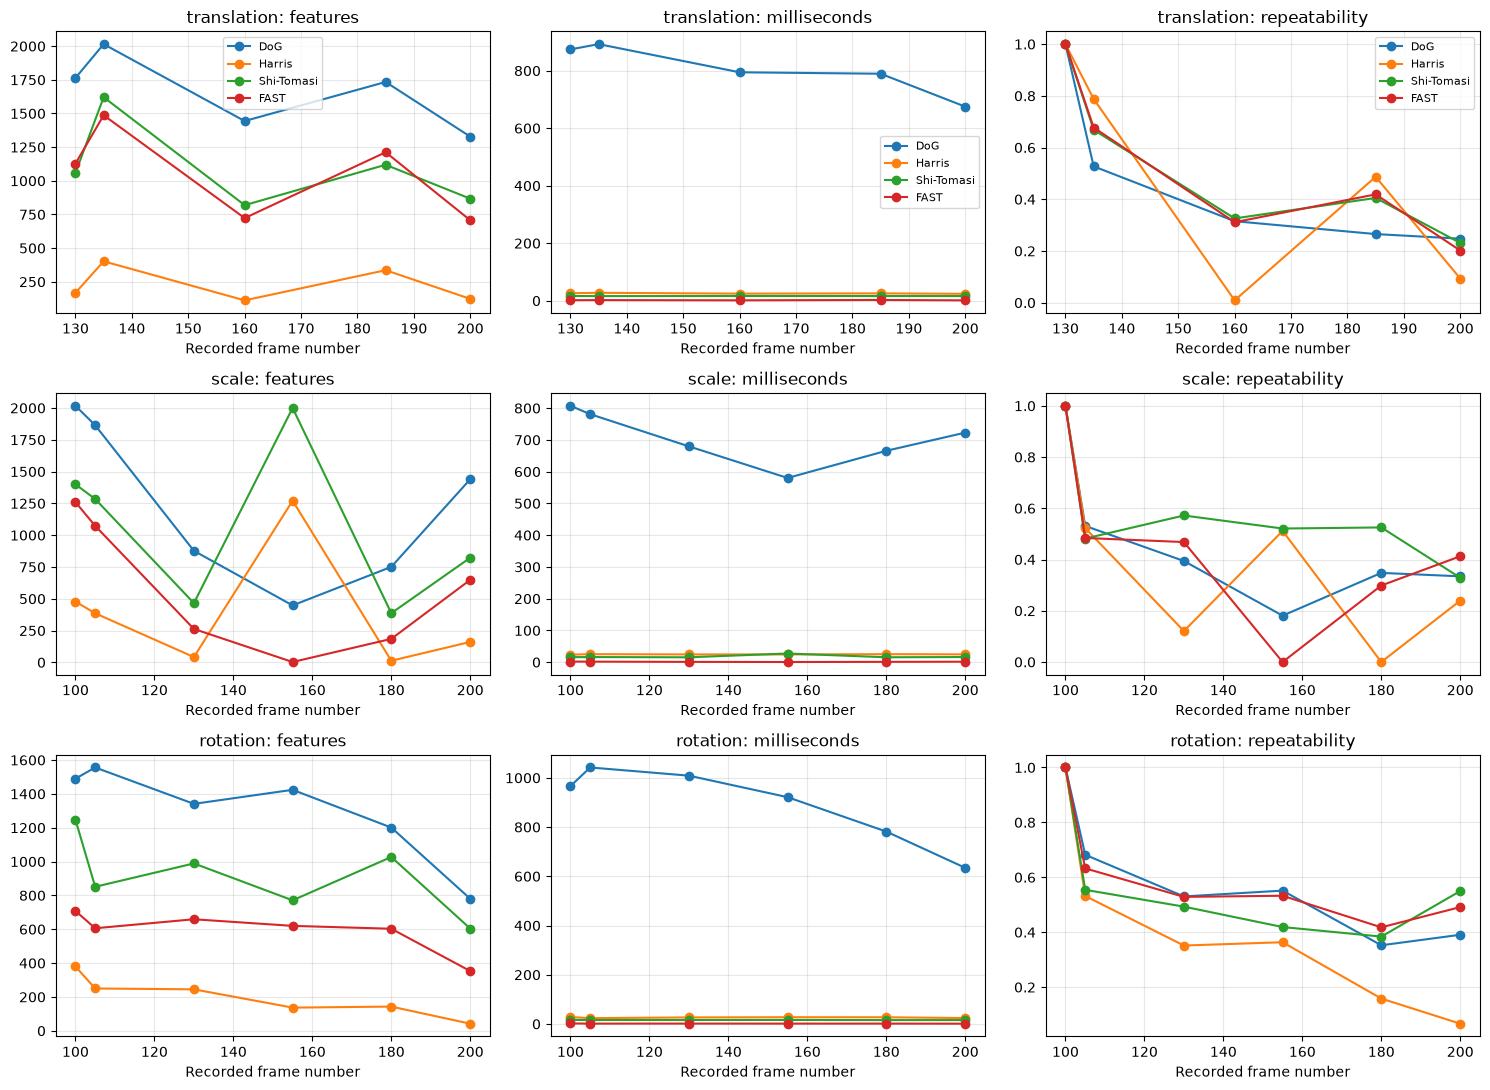

In [36]:
results = comparison.compare_detectors(sequences)
comparison.show_detector_results(results)


2. Implement a method for selecting a subset of features based on contemporary research. The
method must provide a reasonable set of features covering the whole image. Citations are needed
for this. Octrees and ANMS are candidates for this. I will provide the ANMS paper on
Blackboard. 


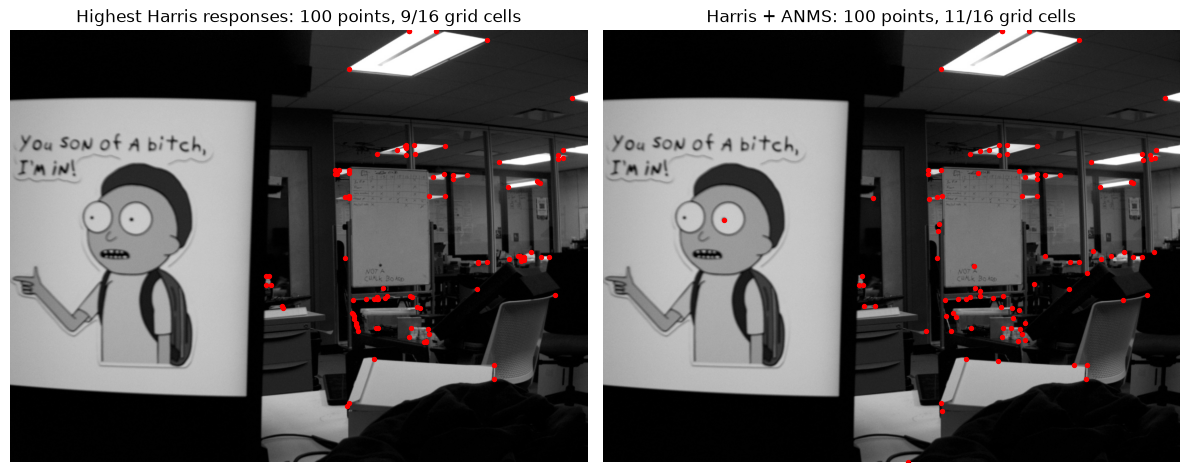

In [37]:
from utils.ANMS import show_anms
selected = show_anms(sequences["translation"][0][1], keep=ANMS_DEMO_KEEP,
                     robust=comparison.SETTINGS["anms_robust"])

3. Conduct feature matching using SIFT, BRIEF, and ORB feature descriptors. Make sure to pick
one type of detections scheme from above to ensure a good comparison. Look at the speed and
quality of matching. Produce a confusion matrix for each one of these. 


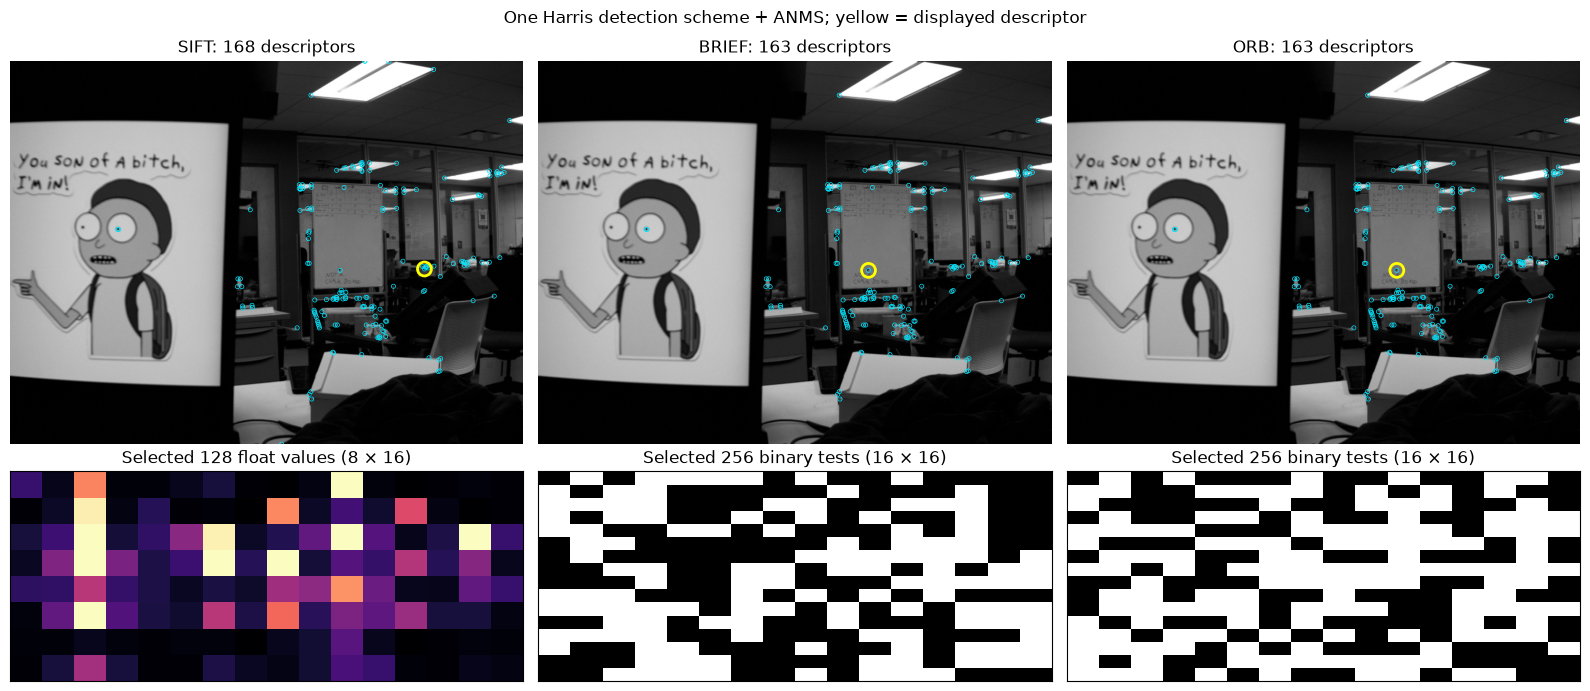

SIFT: mean pair time 131.72 ms
Rows: actual wrong/right; columns: rejected/accepted
[[2857  342]
 [ 146  327]]
Accepted-match precision: 0.489

BRIEF: mean pair time 88.83 ms
Rows: actual wrong/right; columns: rejected/accepted
[[2460  505]
 [  99  348]]
Accepted-match precision: 0.408

ORB: mean pair time 90.63 ms
Rows: actual wrong/right; columns: rejected/accepted
[[2413  551]
 [ 126  297]]
Accepted-match precision: 0.350



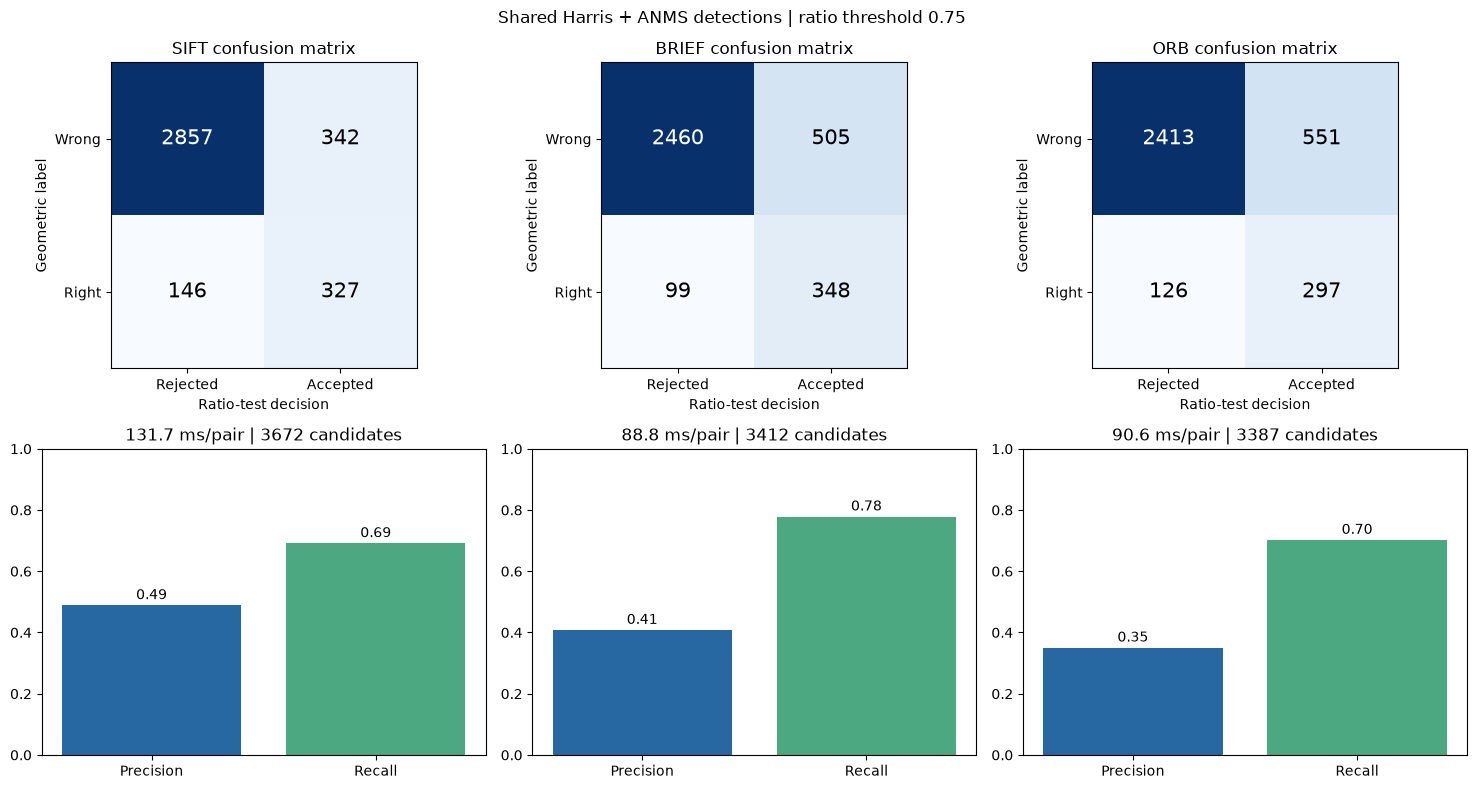

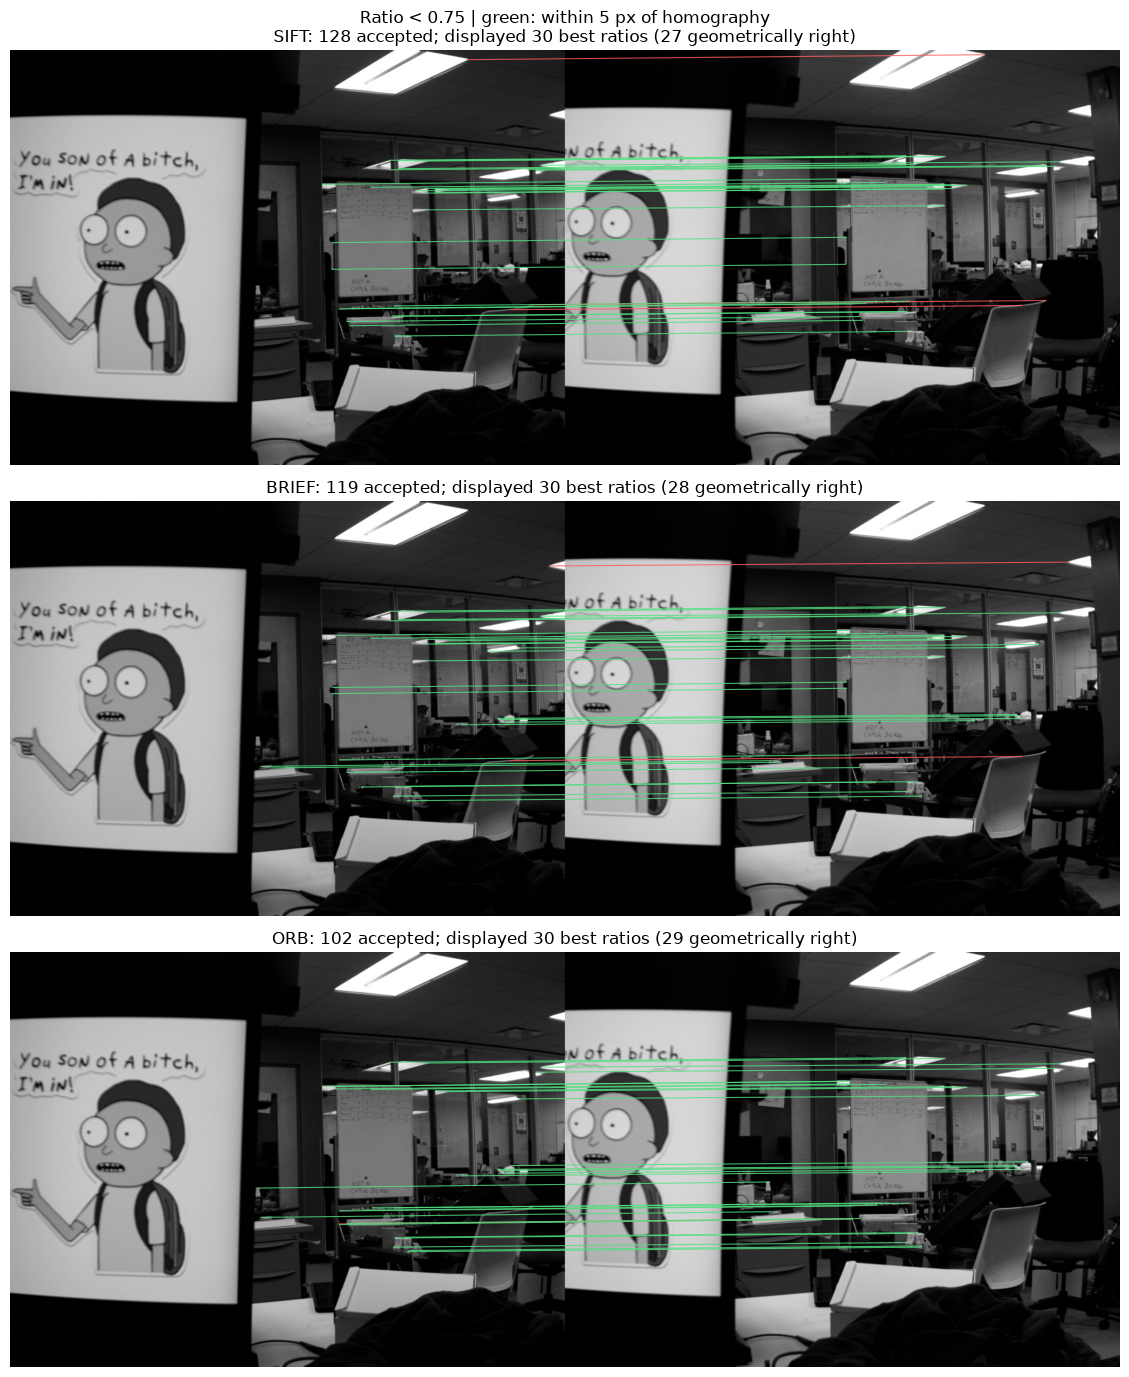

In [38]:
comparison.show_descriptor_visualization(sequences["translation"][0][1])
matches = comparison.compare_descriptors(sequences)
comparison.show_confusion_matrices(matches)
comparison.show_descriptor_summary(matches)
motion, reference, name, target = next(comparison.sampled_pairs(sequences))
comparison.show_match_visualization(reference, target, comparison.homography(reference, target))

4. For the matching method of your choice, construct a ROC curve. Talk about the idea parameters
for your matching technique


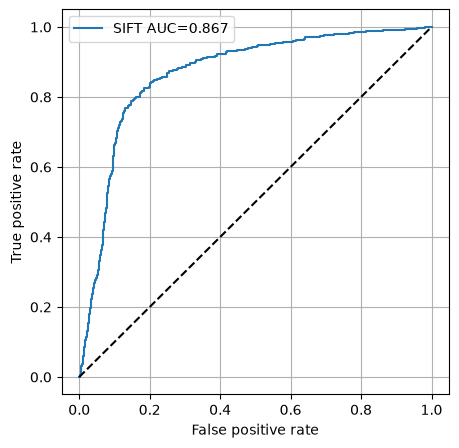

In [39]:
comparison.show_sift_roc(matches)
